# Logistic Regression Project

### Placement Prediction

This project implements Logistic Regression in three ways:

1. Perceptron Trick — From Scratch
2. Logistic Regression — From Scratch
3. Logistic Regression — Scikit-learn

We will use the same dataset and compare the approaches.

## 1. Project Overview

## 2. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 3. Load Dataset

In [2]:
df = pd.read_csv("placement.csv")

df.head()

,Name,Roll No,Branch,Gender,CGPA,10th_percentage,12th_percentage,Project Level,Internships,Certifications,Backlogs,Placed
0,William Johnson,3913839,CSAIML,Male,4.42,95.60,54.02,Advanced,Yes,No,0,0
1,John Martinez,5382514,CSDS,Male,4.13,72.06,51.38,Beginner,No,No,0,0
2,Ashley Smith,6830292,CSDS,Female,6.43,54.90,68.79,Moderate,No,Yes,2,0
3,Ann Wilson,2963711,CSDS,Female,5.24,72.51,61.97,Moderate,No,Yes,0,0
4,Rebecca Peterson,2075489,IT,Female,7.15,69.53,55.80,Advanced,Yes,No,0,1


## 4. Data Understanding

In [3]:
print("Shape:", df.shape)

print("Columns:")

print(df.columns.tolist())

df.info()

print("Missing values:")

print(df.isnull().sum())

print("Target distribution:")

print(df["Placed"].value_counts())

Shape: (1000, 12)
Columns:
['Name', 'Roll No', 'Branch', 'Gender', 'CGPA', '10th_percentage', '12th_percentage', 'Project Level', 'Internships', 'Certifications', 'Backlogs', 'Placed']
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             1000 non-null   str    
 1   Roll No          1000 non-null   int64  
 2   Branch           1000 non-null   str    
 3   Gender           1000 non-null   str    
 4   CGPA             1000 non-null   float64
 5   10th_percentage  1000 non-null   float64
 6   12th_percentage  1000 non-null   float64
 7   Project Level    1000 non-null   str    
 8   Internships      1000 non-null   str    
 9   Certifications   1000 non-null   str    
 10  Backlogs         1000 non-null   int64  
 11  Placed           1000 non-null   int64  
dtypes: float64(3), int64(3), str(6)
memory usage: 127.9 KB
Missing values:


In [4]:
print("Branch:")
print(df["Branch"].value_counts())

print("\nProject Level:")
print(df["Project Level"].value_counts())

print("\nInternships:")
print(df["Internships"].value_counts())

print("\nCertifications:")
print(df["Certifications"].value_counts())

Branch:
Branch
CSAIML    135
CSDS      121
EEE       120
CSE       119
AIDS      117
ECE       101
ME         98
IT         96
CSAI       93
Name: count, dtype: int64

Project Level:
Project Level
Advanced    348
Beginner    339
Moderate    313
Name: count, dtype: int64

Internships:
Internships
No     514
Yes    486
Name: count, dtype: int64

Certifications:
Certifications
No     525
Yes    475
Name: count, dtype: int64


## 5. Exploratory Data Analysis (EDA)

In [5]:
print(df["Branch"].value_counts())

print(df["Project Level"].value_counts())

print(df["Internships"].value_counts())

print(df["Certifications"].value_counts())

df[[

    "Branch",

    "Project Level",

    "Internships",

    "Certifications"

]].head(10)
# We will perform EDA here.
# Target distribution
# Feature distributions
# Relationships between features and placement
# Correlation analysis

Branch
CSAIML    135
CSDS      121
EEE       120
CSE       119
AIDS      117
ECE       101
ME         98
IT         96
CSAI       93
Name: count, dtype: int64
Project Level
Advanced    348
Beginner    339
Moderate    313
Name: count, dtype: int64
Internships
No     514
Yes    486
Name: count, dtype: int64
Certifications
No     525
Yes    475
Name: count, dtype: int64


,Branch,Project Level,Internships,Certifications
0,CSAIML,Advanced,Yes,No
1,CSDS,Beginner,No,No
2,CSDS,Moderate,No,Yes
3,CSDS,Moderate,No,Yes
4,IT,Advanced,Yes,No
5,CSAIML,Advanced,No,No
6,IT,Beginner,Yes,Yes
7,IT,Moderate,Yes,Yes
8,IT,Beginner,No,No
9,EEE,Advanced,No,No


In [6]:
df[
    [
        "CGPA",
        "10th_percentage",
        "12th_percentage",
        "Backlogs"
    ]
].describe()

,CGPA,10th_percentage,12th_percentage,Backlogs
count,1000.000000,1000.000000,1000.00000,1000.000000
mean,6.544140,75.110910,74.87233,2.414000
std,2.023294,14.526271,14.07197,1.723826
min,3.010000,50.010000,50.11000,0.000000
25%,4.800000,62.712500,62.94250,1.000000
50%,6.400000,74.955000,75.04000,2.000000
75%,8.370000,87.570000,86.64250,4.000000
max,9.990000,99.960000,99.93000,5.000000


## 6. Data Cleaning

In [7]:
# Missing values
# Duplicate rows
# Incorrect data types
# Outliers if necessary
# We will decide what to clean after inspecting the dataset.

## 7. Feature Selection

In [8]:
df_model = df.drop(
    columns=["Name", "Roll No", "Gender"]
)

df_model.head()

,Branch,CGPA,10th_percentage,12th_percentage,Project Level,Internships,Certifications,Backlogs,Placed
0,CSAIML,4.42,95.60,54.02,Advanced,Yes,No,0,0
1,CSDS,4.13,72.06,51.38,Beginner,No,No,0,0
2,CSDS,6.43,54.90,68.79,Moderate,No,Yes,2,0
3,CSDS,5.24,72.51,61.97,Moderate,No,Yes,0,0
4,IT,7.15,69.53,55.80,Advanced,Yes,No,0,1


In [9]:
X = df_model.drop(columns=["Placed"])
y = df_model["Placed"]

In [10]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 8)
y shape: (1000,)


In [11]:
print(df_model.shape)

(1000, 9)


## 9. Train/Test Split

In [12]:
np.random.seed(42)

indices = np.random.permutation(len(X))

train_size = int(0.8 * len(X))

train_indices = indices[:train_size]
test_indices = indices[train_size:]
X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()

y_train = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (800, 8)
X_test : (200, 8)
y_train: (800,)
y_test : (200,)


## 8. Encoding

In [13]:
binary_mapping = {
    "No": 0,
    "Yes": 1
}

X_train["Internships"] = X_train["Internships"].map(binary_mapping)
X_test["Internships"] = X_test["Internships"].map(binary_mapping)

In [14]:
X_train["Certifications"] = X_train["Certifications"].map(binary_mapping)
X_test["Certifications"] = X_test["Certifications"].map(binary_mapping)

In [15]:
project_mapping = {
    "Beginner": 0,
    "Moderate": 1,
    "Advanced": 2
}

X_train["Project Level"] = X_train["Project Level"].map(project_mapping)
X_test["Project Level"] = X_test["Project Level"].map(project_mapping)

In [16]:
X_train = pd.get_dummies(
    X_train,
    columns=["Branch"],
    dtype=int
)

X_test = pd.get_dummies(
    X_test,
    columns=["Branch"],
    dtype=int
)

In [17]:
print(X_train.shape)
print(X_test.shape)

(800, 16)
(200, 16)


In [18]:
print(X_train.dtypes)

CGPA               float64
10th_percentage    float64
12th_percentage    float64
Project Level        int64
Internships          int64
Certifications       int64
Backlogs             int64
Branch_AIDS          int64
Branch_CSAI          int64
Branch_CSAIML        int64
Branch_CSDS          int64
Branch_CSE           int64
Branch_ECE           int64
Branch_EEE           int64
Branch_IT            int64
Branch_ME            int64
dtype: object


In [19]:
print("Missing values in X_train:")
print(X_train.isnull().sum().sum())

print("\nMissing values in X_test:")
print(X_test.isnull().sum().sum())

Missing values in X_train:
0

Missing values in X_test:
0


## 10. Feature Scaling

In [20]:
# Feature scaling will be implemented manually.
# We will use the training data to calculate scaling parameters.

mean = X_train.mean()
std = X_train.std()
X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std
print(X_train_scaled.head())
print(X_train_scaled.mean())
print(X_train_scaled.std())

         CGPA  10th_percentage  12th_percentage  Project Level  Internships  \
521  0.306199        -0.627538         1.205924      -1.197935     1.022119   
737  0.350290         1.600551         1.225910      -1.197935     1.022119   
740  1.099837        -1.171310         0.534955      -1.197935    -0.977136   
660 -0.658903         0.466890         0.088833       0.003002    -0.977136   
411 -1.717085         1.694851         0.557797       1.203940    -0.977136   

     Certifications  Backlogs  Branch_AIDS  Branch_CSAI  Branch_CSAIML  \
521       -0.941108  0.358784    -0.355812    -0.316681      -0.386314   
737        1.061249 -1.387832    -0.355812    -0.316681      -0.386314   
740       -0.941108  1.523195    -0.355812    -0.316681      -0.386314   
660        1.061249 -1.387832    -0.355812    -0.316681      -0.386314   
411       -0.941108 -0.805627    -0.355812    -0.316681      -0.386314   

     Branch_CSDS  Branch_CSE  Branch_ECE  Branch_EEE  Branch_IT  Branch_ME  
521

In [21]:
X_train_scaled

,CGPA,10th_percentage,12th_percentage,Project Level,Internships,Certifications,Backlogs,Branch_AIDS,Branch_CSAI,Branch_CSAIML,Branch_CSDS,Branch_CSE,Branch_ECE,Branch_EEE,Branch_IT,Branch_ME
521,0.306199,-0.627538,1.205924,-1.197935,1.022119,-0.941108,0.358784,-0.355812,-0.316681,-0.386314,-0.375567,-0.362460,-0.340023,2.690421,-0.340023,-0.328479
737,0.350290,1.600551,1.225910,-1.197935,1.022119,1.061249,-1.387832,-0.355812,-0.316681,-0.386314,-0.375567,2.755476,-0.340023,-0.371224,-0.340023,-0.328479
740,1.099837,-1.171310,0.534955,-1.197935,-0.977136,-0.941108,1.523195,-0.355812,-0.316681,-0.386314,-0.375567,-0.362460,-0.340023,2.690421,-0.340023,-0.328479
660,-0.658903,0.466890,0.088833,0.003002,-0.977136,1.061249,-1.387832,-0.355812,-0.316681,-0.386314,2.659315,-0.362460,-0.340023,-0.371224,-0.340023,-0.328479
411,-1.717085,1.694851,0.557797,1.203940,-0.977136,-0.941108,-0.805627,-0.355812,-0.316681,-0.386314,-0.375567,-0.362460,-0.340023,-0.371224,2.937304,-0.328479
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619,-0.805872,-1.541626,1.253034,0.003002,-0.977136,-0.941108,-1.387832,-0.355812,-0.316681,2.585332,-0.375567,-0.362460,-0.340023,-0.371224,-0.340023,-0.328479
855,1.334988,-0.698435,0.613473,1.203940,1.022119,-0.941108,0.940989,-0.355812,-0.316681,-0.386314,-0.375567,-0.362460,-0.340023,-0.371224,-0.340023,3.040533
803,-0.198397,-1.171999,-0.676357,-1.197935,-0.977136,-0.941108,-0.223421,2.806961,-0.316681,-0.386314,-0.375567,-0.362460,-0.340023,-0.371224,-0.340023,-0.328479
645,1.472160,-0.803748,-0.975437,1.203940,1.022119,-0.941108,0.940989,-0.355812,-0.316681,-0.386314,-0.375567,2.755476,-0.340023,-0.371224,-0.340023,-0.328479


In [22]:
scale_features = [
    "CGPA",
    "10th_percentage",
    "12th_percentage",
    "Backlogs",
    "Project Level"
]

mean = X_train[scale_features].mean()
std = X_train[scale_features].std()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_features] = (
    X_train[scale_features] - mean
) / std

X_test_scaled[scale_features] = (
    X_test[scale_features] - mean
) / std

In [23]:
X_train_scaled.head()

,CGPA,10th_percentage,12th_percentage,Project Level,Internships,Certifications,Backlogs,Branch_AIDS,Branch_CSAI,Branch_CSAIML,Branch_CSDS,Branch_CSE,Branch_ECE,Branch_EEE,Branch_IT,Branch_ME
521,0.306199,-0.627538,1.205924,-1.197935,1,0,0.358784,0,0,0,0,0,0,1,0,0
737,0.350290,1.600551,1.225910,-1.197935,1,1,-1.387832,0,0,0,0,1,0,0,0,0
740,1.099837,-1.171310,0.534955,-1.197935,0,0,1.523195,0,0,0,0,0,0,1,0,0
660,-0.658903,0.466890,0.088833,0.003002,0,1,-1.387832,0,0,0,1,0,0,0,0,0
411,-1.717085,1.694851,0.557797,1.203940,0,0,-0.805627,0,0,0,0,0,0,0,1,0


In [24]:
binary_columns = [
    "Internships",
    "Certifications"
] + [col for col in X_train.columns if col.startswith("Branch_")]

print(X_train_scaled[binary_columns].head())

     Internships  Certifications  Branch_AIDS  Branch_CSAI  Branch_CSAIML  \
521            1               0            0            0              0   
737            1               1            0            0              0   
740            0               0            0            0              0   
660            0               1            0            0              0   
411            0               0            0            0              0   

     Branch_CSDS  Branch_CSE  Branch_ECE  Branch_EEE  Branch_IT  Branch_ME  
521            0           0           0           1          0          0  
737            0           1           0           0          0          0  
740            0           0           0           1          0          0  
660            1           0           0           0          0          0  
411            0           0           0           0          1          0  


## 11. Perceptron Trick — From Scratch

In [25]:
# Perceptron implementation will go here.
X_train_np = X_train_scaled.to_numpy(dtype=float)
X_test_np = X_test_scaled.to_numpy(dtype=float)

y_train_np = y_train.to_numpy(dtype=int)
y_test_np = y_test.to_numpy(dtype=int)
class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs

        self.weights = None
        self.bias = None
        self.errors = []

    def fit(self, X, y):

        n_samples, n_features = X.shape

        # Initialize weights
        self.weights = np.zeros(n_features)

        # Initialize bias
        self.bias = 0

        for epoch in range(self.epochs):

            error_count = 0

            for i in range(n_samples):

                # Linear equation
                z = np.dot(X[i], self.weights) + self.bias

                # Prediction
                y_pred = 1 if z > 0 else 0

                # Calculate update
                update = self.learning_rate * (y[i] - y_pred)

                # Update weights
                self.weights += update * X[i]

                # Update bias
                self.bias += update

                if update != 0:
                    error_count += 1

            self.errors.append(error_count)

    def predict(self, X):

        z = np.dot(X, self.weights) + self.bias

        return (z > 0).astype(int)
#
# z = w.X + b
# prediction = step(z)
# update weights when prediction is incorrect



In [26]:
perceptron = Perceptron(
    learning_rate=0.01,
    epochs=100
)

perceptron.fit(X_train_np, y_train_np)

In [27]:
y_pred_perceptron = perceptron.predict(X_test_np)

print(y_pred_perceptron[:20])

[0 1 0 0 0 0 0 1 1 0 0 1 0 1 0 0 0 0 0 0]


In [28]:
accuracy = np.mean(y_pred_perceptron == y_test_np)

print(f"Perceptron Accuracy: {accuracy * 100:.2f}%")

Perceptron Accuracy: 88.00%


In [29]:
print("Errors in first epoch:", perceptron.errors[0])
print("Errors in last epoch :", perceptron.errors[-1])

Errors in first epoch: 132
Errors in last epoch : 115


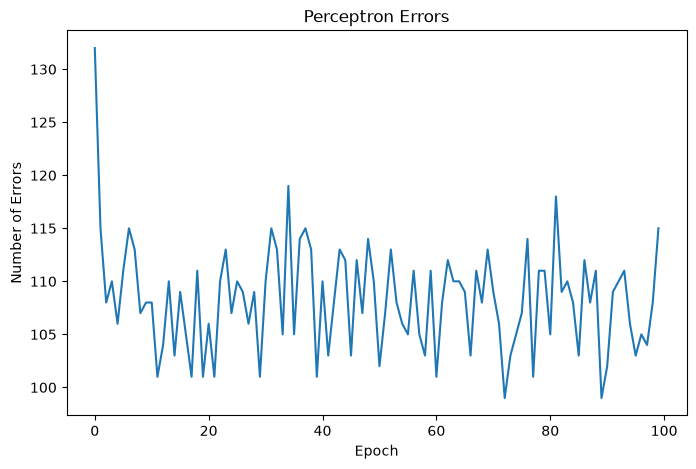

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(perceptron.errors)

plt.xlabel("Epoch")
plt.ylabel("Number of Errors")
plt.title("Perceptron Errors")

plt.show()

## 12. Logistic Regression — From Scratch

In [31]:
# Logistic Regression implementation will go here.
#
# 1. Linear combination
import numpy as np
import matplotlib.pyplot as plt

X_train_np = X_train_scaled.to_numpy(dtype=float)
X_test_np = X_test_scaled.to_numpy(dtype=float)

y_train_np = y_train.to_numpy(dtype=int)
y_test_np = y_test.to_numpy(dtype=int)

print("X_train:", X_train_np.shape)
print("X_test :", X_test_np.shape)
print("y_train:", y_train_np.shape)
print("y_test :", y_test_np.shape)
# 2. Sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
# 3. Binary cross-entropy loss
# 4. Gradients
# 5. Gradient descent
# 6. Prediction

class LogisticRegressionScratch:

    def __init__(self, learning_rate=0.01, epochs=1000):

        self.learning_rate = learning_rate
        self.epochs = epochs

        self.weights = None
        self.bias = None

        self.loss_history = []


    def fit(self, X, y):

        n_samples, n_features = X.shape

        # -----------------------------
        # Initialize parameters
        # -----------------------------

        self.weights = np.zeros(n_features)
        self.bias = 0

        # -----------------------------
        # Gradient Descent
        # -----------------------------

        for epoch in range(self.epochs):

            # 1. Linear equation
            #
            # z = Xw + b
            #
            z = np.dot(X, self.weights) + self.bias


            # 2. Sigmoid
            #
            # probability between 0 and 1
            #
            probabilities = sigmoid(z)


            # 3. Binary Cross-Entropy Loss
            #

            epsilon = 1e-15

            probabilities_clipped = np.clip(
                probabilities,
                epsilon,
                1 - epsilon
            )

            loss = -np.mean(
                y * np.log(probabilities_clipped)
                +
                (1 - y) * np.log(1 - probabilities_clipped)
            )

            self.loss_history.append(loss)


            # 4. Calculate gradients
            #

            error = probabilities - y

            dw = (1 / n_samples) * np.dot(
                X.T,
                error
            )

            db = (1 / n_samples) * np.sum(error)


            # 5. Gradient Descent update
            #

            self.weights -= self.learning_rate * dw

            self.bias -= self.learning_rate * db


    def predict_probability(self, X):

        # Linear equation
        z = np.dot(X, self.weights) + self.bias

        # Sigmoid
        probabilities = sigmoid(z)

        return probabilities


    def predict(self, X):

        probabilities = self.predict_probability(X)

        # Threshold = 0.5
        predictions = (probabilities >= 0.5).astype(int)

        return predictions



X_train: (800, 16)
X_test : (200, 16)
y_train: (800,)
y_test : (200,)


In [32]:
log_reg = LogisticRegressionScratch(
    learning_rate=0.01,
    epochs=1000
)

In [33]:
log_reg.fit(
    X_train_np,
    y_train_np
)

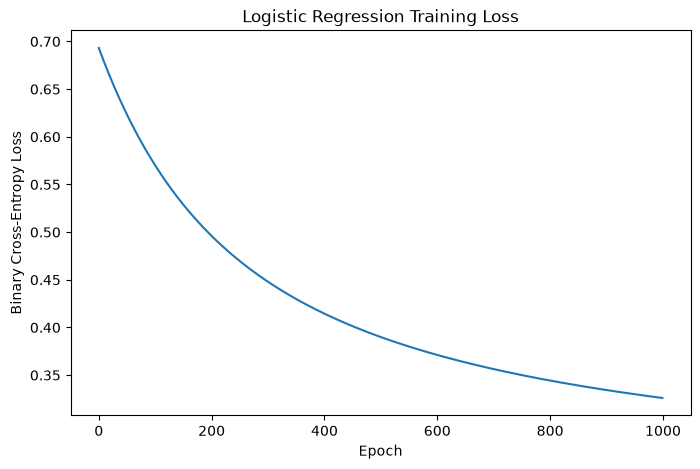

<Figure size 640x480 with 0 Axes>

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(log_reg.loss_history)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Logistic Regression Training Loss")

plt.show()
plt.savefig("logistic_regression_loss.png", dpi=300, bbox_inches="tight")

In [35]:
probabilities = log_reg.predict_probability(X_test_np)

print(probabilities[:10])

[0.51335838 0.76006272 0.41756255 0.28506788 0.08179675 0.34207611
 0.13649117 0.71973407 0.72698863 0.02254943]


In [36]:
y_pred = log_reg.predict(X_test_np)

print(y_pred[:20])

[1 1 0 0 0 0 0 1 1 0 0 1 0 1 0 0 0 0 0 0]


In [37]:
accuracy = np.mean(y_pred == y_test_np)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 86.00%


In [38]:
print("Weights:")
print(log_reg.weights)

print("\nBias:")
print(log_reg.bias)

Weights:
[ 1.51857987 -0.06613235  0.03830535  0.1702213  -0.04890375 -0.15446971
 -0.39339226 -0.13872743 -0.07460332 -0.09727878 -0.09958514 -0.06054073
 -0.14438835  0.02005397 -0.04000064 -0.00224333]

Bias:
-0.6373137512148


In [39]:
feature_names = X_train_scaled.columns

weights_df = pd.DataFrame({
    "Feature": feature_names,
    "Weight": log_reg.weights
})

weights_df.sort_values(
    by="Weight",
    ascending=False
)

,Feature,Weight
0,CGPA,1.518580
3,Project Level,0.170221
2,12th_percentage,0.038305
13,Branch_EEE,0.020054
15,Branch_ME,-0.002243
14,Branch_IT,-0.040001
4,Internships,-0.048904
11,Branch_CSE,-0.060541
1,10th_percentage,-0.066132
8,Branch_CSAI,-0.074603


## 13. Logistic Regression — Scikit-learn

In [40]:
from sklearn.linear_model import LogisticRegression

log_reg_sklearn = LogisticRegression(
    max_iter=1000
)

In [41]:
log_reg_sklearn.fit(
    X_train_scaled,
    y_train
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [42]:
y_pred_sklearn = log_reg_sklearn.predict(
    X_test_scaled
)

In [43]:
accuracy_sklearn = np.mean(
    y_pred_sklearn == y_test.to_numpy()
)

print(f"Sklearn Logistic Regression Accuracy: {accuracy_sklearn * 100:.2f}%")

Sklearn Logistic Regression Accuracy: 88.00%


In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=2000),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [45]:
grid_search.fit(X_train_scaled, y_train)
print("Best Parameters:")
print(grid_search.best_params_)
print("Best CV Accuracy:")
print(grid_search.best_score_)
print(
    f"Best CV Accuracy: "
    f"{grid_search.best_score_ * 100:.2f}%"
)

best_model = grid_search.best_estimator_
y_pred_grid = best_model.predict(X_test_scaled)

accuracy_grid = np.mean(
    y_pred_grid == y_test.to_numpy()
)

print(
    f"GridSearchCV Test Accuracy: "
    f"{accuracy_grid * 100:.2f}%"
)

Best Parameters:
{'C': 0.1, 'solver': 'liblinear'}
Best CV Accuracy:
0.89375
Best CV Accuracy: 89.38%
GridSearchCV Test Accuracy: 86.50%


## 14. Model Comparison

In [46]:
# ============================================================
# SECTION 14 — MODEL COMPARISON
# ============================================================
#
# Models:
# 1. Perceptron                  → From Scratch
# 2. Logistic Regression         → From Scratch + Gradient Descent
# 3. Logistic Regression         → Scikit-Learn
#
# Metrics:
# - Accuracy
# - Precision
# - Recall
# - F1 Score
# - ROC-AUC
# - Training Time
# - Predictions
# ============================================================


import numpy as np
import pandas as pd
import time

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# 1. TRAINING TIME
# ============================================================

# ------------------------------------------------------------
# Perceptron
# ------------------------------------------------------------

start_time = time.perf_counter()

perceptron.fit(
    X_train_np,
    y_train_np
)

perceptron_training_time = time.perf_counter() - start_time


# ------------------------------------------------------------
# Logistic Regression — Scratch
# ------------------------------------------------------------

start_time = time.perf_counter()

log_reg.fit(
    X_train_np,
    y_train_np
)

scratch_training_time = time.perf_counter() - start_time


# ------------------------------------------------------------
# Logistic Regression — sklearn
# ------------------------------------------------------------

start_time = time.perf_counter()

log_reg_sklearn.fit(
    X_train_scaled,
    y_train
)

sklearn_training_time = time.perf_counter() - start_time


# ============================================================
# 2. PREDICTIONS
# ============================================================

# Perceptron
y_pred_perceptron = perceptron.predict(
    X_test_np
)


# Logistic Regression — Scratch
y_pred_scratch = log_reg.predict(
    X_test_np
)


# Logistic Regression — sklearn
y_pred_sklearn = log_reg_sklearn.predict(
    X_test_scaled
)


# ============================================================
# 3. SCORES FOR ROC-AUC
# ============================================================

# ------------------------------------------------------------
# Perceptron
# ------------------------------------------------------------
#
# Perceptron gives a decision score:
#
# score = Xw + b
#
# We need the raw decision score for ROC-AUC,
# not only the 0/1 predictions.
# ------------------------------------------------------------

perceptron_scores = (
    np.dot(
        X_test_np,
        perceptron.weights
    )
    + perceptron.bias
)


# ------------------------------------------------------------
# Logistic Regression — Scratch
# ------------------------------------------------------------

scratch_probabilities = log_reg.predict_probability(
    X_test_np
)


# ------------------------------------------------------------
# Logistic Regression — sklearn
# ------------------------------------------------------------

sklearn_probabilities = log_reg_sklearn.predict_proba(
    X_test_scaled
)[:, 1]


# ============================================================
# 4. STORE ALL MODELS
# ============================================================

models = {

    "Perceptron": {
        "predictions": y_pred_perceptron,
        "scores": perceptron_scores,
        "training_time": perceptron_training_time
    },

    "Logistic Regression (Scratch)": {
        "predictions": y_pred_scratch,
        "scores": scratch_probabilities,
        "training_time": scratch_training_time
    },

    "Logistic Regression (Sklearn)": {
        "predictions": y_pred_sklearn,
        "scores": sklearn_probabilities,
        "training_time": sklearn_training_time
    }
}


# ============================================================
# 5. CALCULATE METRICS
# ============================================================

results = []


for name, model in models.items():

    predictions = model["predictions"]
    scores = model["scores"]


    # --------------------------------------------------------
    # Calculate metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test_np,
        predictions
    )


    precision = precision_score(
        y_test_np,
        predictions,
        zero_division=0
    )


    recall = recall_score(
        y_test_np,
        predictions,
        zero_division=0
    )


    f1 = f1_score(
        y_test_np,
        predictions,
        zero_division=0
    )


    roc_auc = roc_auc_score(
        y_test_np,
        scores
    )


    training_time = model["training_time"]


    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "ROC-AUC": roc_auc,

        "Training Time (sec)": training_time
    })


# ============================================================
# 6. CREATE COMPARISON DATAFRAME
# ============================================================

comparison_df = pd.DataFrame(
    results
)


# ============================================================
# 7. DISPLAY RESULTS
# ============================================================

print("\n")
print("=" * 90)
print("MODEL COMPARISON")
print("=" * 90)

display(comparison_df)


# ============================================================
# 8. DISPLAY PERCENTAGES
# ============================================================

comparison_percentage = comparison_df.copy()


metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]


for column in metric_columns:

    comparison_percentage[column] = (
        comparison_percentage[column] * 100
    ).round(2)


comparison_percentage["Training Time (sec)"] = (
    comparison_percentage["Training Time (sec)"]
    .round(6)
)


print("\n")
print("=" * 90)
print("MODEL COMPARISON — PERCENTAGES")
print("=" * 90)

display(comparison_percentage)


# ============================================================
# 9. CONFUSION MATRICES
# ============================================================

for name, model in models.items():

    predictions = model["predictions"]

    cm = confusion_matrix(
        y_test_np,
        predictions
    )

    print("\n")
    print("=" * 60)
    print(name)
    print("=" * 60)

    print("\nConfusion Matrix:")
    print(cm)


# ============================================================
# 10. CLASSIFICATION REPORTS
# ============================================================

for name, model in models.items():

    predictions = model["predictions"]

    print("\n")
    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test_np,
            predictions,
            target_names=[
                "Not Placed",
                "Placed"
            ],
            zero_division=0
        )
    )


# ============================================================
# 11. SHOW FIRST 20 PREDICTIONS
# ============================================================

prediction_df = pd.DataFrame({

    "Actual": y_test_np[:20],

    "Perceptron": y_pred_perceptron[:20],

    "Logistic Scratch": y_pred_scratch[:20],

    "Logistic Sklearn": y_pred_sklearn[:20]
})


print("\n")
print("=" * 70)
print("FIRST 20 PREDICTIONS")
print("=" * 70)

display(prediction_df)


# ============================================================
# 12. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("FINAL ACCURACY")
print("=" * 70)

for name, model in models.items():

    accuracy = accuracy_score(
        y_test_np,
        model["predictions"]
    )

    print(
        f"{name:<35} : {accuracy * 100:.2f}%"
    )



MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (sec)
0,Perceptron,0.88,0.818182,0.692308,0.750000,0.946076,2.000230
1,Logistic Regression (Scratch),0.86,0.714286,0.769231,0.740741,0.948025,0.257981
2,Logistic Regression (Sklearn),0.88,0.750000,0.807692,0.777778,0.952833,0.024867




MODEL COMPARISON — PERCENTAGES


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (sec)
0,Perceptron,88.0,81.82,69.23,75.00,94.61,2.000230
1,Logistic Regression (Scratch),86.0,71.43,76.92,74.07,94.80,0.257981
2,Logistic Regression (Sklearn),88.0,75.00,80.77,77.78,95.28,0.024867




Perceptron

Confusion Matrix:
[[140   8]
 [ 16  36]]


Logistic Regression (Scratch)

Confusion Matrix:
[[132  16]
 [ 12  40]]


Logistic Regression (Sklearn)

Confusion Matrix:
[[134  14]
 [ 10  42]]


Perceptron
              precision    recall  f1-score   support

  Not Placed       0.90      0.95      0.92       148
      Placed       0.82      0.69      0.75        52

    accuracy                           0.88       200
   macro avg       0.86      0.82      0.84       200
weighted avg       0.88      0.88      0.88       200



Logistic Regression (Scratch)
              precision    recall  f1-score   support

  Not Placed       0.92      0.89      0.90       148
      Placed       0.71      0.77      0.74        52

    accuracy                           0.86       200
   macro avg       0.82      0.83      0.82       200
weighted avg       0.86      0.86      0.86       200



Logistic Regression (Sklearn)
              precision    recall  f1-score   support

  Not Place

,Actual,Perceptron,Logistic Scratch,Logistic Sklearn
0,1,0,1,1
1,1,1,1,1
2,0,0,0,1
3,0,0,0,0
4,0,0,0,0
5,0,0,0,0
6,0,0,0,0
7,1,1,1,1
8,1,1,1,1
9,0,0,0,0




FINAL ACCURACY
Perceptron                          : 88.00%
Logistic Regression (Scratch)       : 86.00%
Logistic Regression (Sklearn)       : 88.00%


## 15. Conclusions

### Final Conclusions

We will summarize what we learned from:

- Perceptron Trick
- Logistic Regression from scratch
- Scikit-learn Logistic Regression
- Differences in performance
- Mathematical understanding
- Practical implementation